# Sample Portfolio Build

This case study builds a sample multi-asset portfolio using synthetic return assumptions. It connects portfolio theory, optimization, backtesting, and performance metrics.

Abbreviations used in this notebook:

- **ETF**: Exchange-Traded Fund.
- **CAGR**: Compound Annual Growth Rate.
- **MDD**: Maximum Drawdown.
- **IR**: Information Ratio.
- **CHF**: Swiss franc, used only as an illustrative currency.

## 1. Intuition

A portfolio case study starts with an investor objective. Here the objective is balanced growth: participate in equity upside, reduce drawdowns with bonds, and keep enough diversification across real assets and commodities.

## 2. Mathematics

Portfolio return:

$$
R_p = \sum_i w_i R_i
$$

Portfolio volatility:

$$
\sigma_p = \sqrt{w^T\Sigma w}
$$

Sharpe ratio:

$$
Sharpe = \frac{R_p - R_f}{\sigma_p}
$$

Maximum drawdown:

$$
MDD = \min_t \left(\frac{Wealth_t}{Peak_t} - 1\right)
$$

## 3. Implementation

We generate synthetic asset returns and compare a policy portfolio with an equal-weight benchmark.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "03_portfolio_management" / "portfolio_utils.py"
spec = importlib.util.spec_from_file_location("portfolio_utils", helper_path)
portfolio_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(portfolio_utils)

plt.style.use("seaborn-v0_8-whitegrid")

returns = portfolio_utils.generate_synthetic_returns(periods=756, seed=909)
assets = returns.columns.tolist()
policy_weights = pd.Series({
    "Global Equity": 0.34,
    "Swiss Equity": 0.18,
    "Bonds": 0.30,
    "Real Estate": 0.12,
    "Commodities": 0.06,
})
equal_weights = pd.Series(1 / len(assets), index=assets)

policy_returns = returns @ policy_weights
benchmark_returns = returns @ equal_weights
policy_weights.to_frame("policy_weight")

,policy_weight
Global Equity,0.34
Swiss Equity,0.18
Bonds,0.30
Real Estate,0.12
Commodities,0.06


In [2]:
def summary(series, benchmark=None):
    dd = portfolio_utils.drawdown(series)["drawdown"]
    ann_return = portfolio_utils.annualized_return(series)
    ann_vol = portfolio_utils.annualized_volatility(series)
    output = pd.Series({
        "cagr": ann_return,
        "volatility": ann_vol,
        "sharpe": portfolio_utils.sharpe_ratio(ann_return, ann_vol, 0.015),
        "max_drawdown": dd.min(),
    })
    if benchmark is not None:
        active = series - benchmark
        te = active.std() * np.sqrt(252)
        output["tracking_error"] = te
        output["information_ratio"] = (portfolio_utils.annualized_return(series) - portfolio_utils.annualized_return(benchmark)) / te
    return output

metrics = pd.DataFrame({
    "policy_portfolio": summary(policy_returns, benchmark_returns),
    "equal_weight_benchmark": summary(benchmark_returns),
})
metrics.round(4)

,policy_portfolio,equal_weight_benchmark
cagr,0.0461,0.0160
information_ratio,1.1206,NaN
max_drawdown,-0.1472,-0.1723
sharpe,0.3590,0.0111
tracking_error,0.0269,NaN
volatility,0.0866,0.0875


## 4. Visualization

Portfolio case studies should show weights, growth of wealth, and drawdowns.

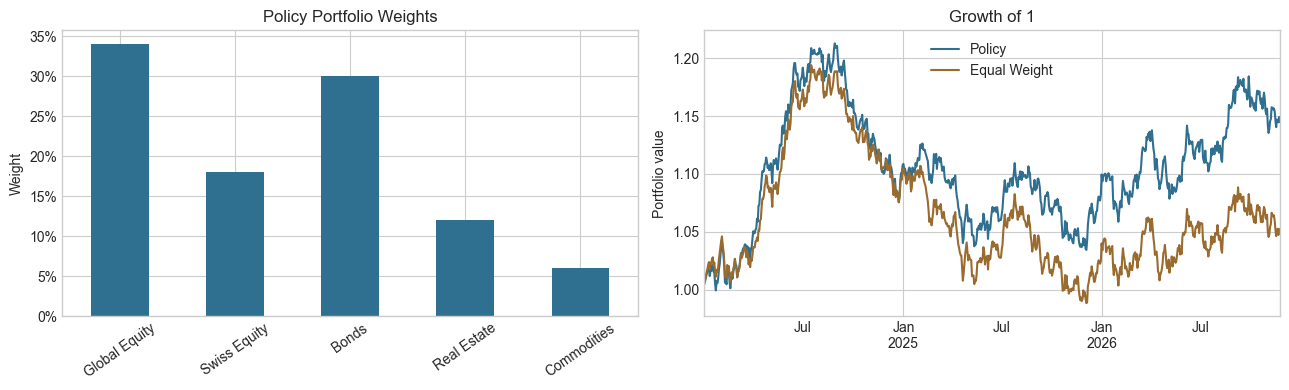

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
policy_weights.plot(kind="bar", ax=axes[0], color="#2f6f8f")
axes[0].set_title("Policy Portfolio Weights")
axes[0].set_ylabel("Weight")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].tick_params(axis="x", rotation=35)

wealth = (1 + pd.DataFrame({"Policy": policy_returns, "Equal Weight": benchmark_returns})).cumprod()
wealth.plot(ax=axes[1], color=["#2f6f8f", "#9a6b2f"])
axes[1].set_title("Growth of 1")
axes[1].set_ylabel("Portfolio value")
plt.tight_layout(); plt.show()

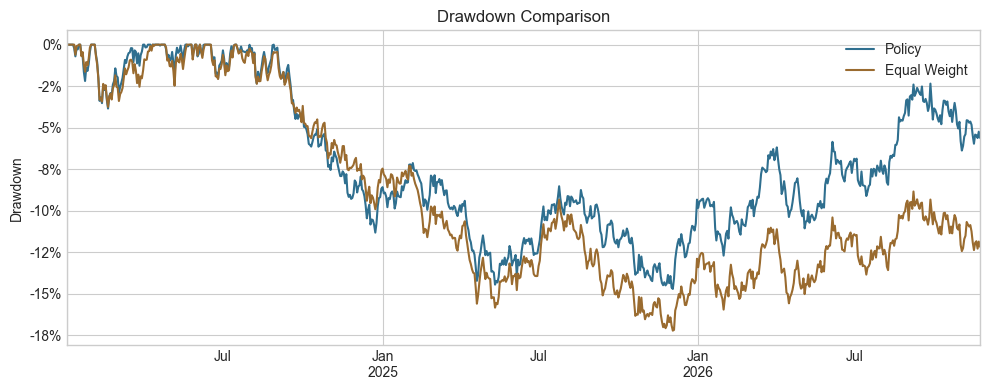

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
portfolio_utils.drawdown(policy_returns)["drawdown"].plot(ax=ax, color="#2f6f8f", label="Policy")
portfolio_utils.drawdown(benchmark_returns)["drawdown"].plot(ax=ax, color="#9a6b2f", label="Equal Weight")
ax.set_title("Drawdown Comparison")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout(); plt.show()

## 5. Application

A sample portfolio should connect investor objectives with allocation choices. This policy portfolio emphasizes diversification and drawdown control through a meaningful bond allocation, while still keeping more than half of capital in equities and real assets.

In [5]:
covariance = returns.cov() * 252
portfolio_vol = np.sqrt(policy_weights.T @ covariance @ policy_weights)
risk_contribution = policy_weights * (covariance @ policy_weights) / portfolio_vol
risk_contribution = risk_contribution / risk_contribution.sum()
pd.DataFrame({"capital_weight": policy_weights, "risk_contribution": risk_contribution}).round(3)

,capital_weight,risk_contribution
Global Equity,0.34,0.577
Swiss Equity,0.18,0.250
Bonds,0.30,0.018
Real Estate,0.12,0.110
Commodities,0.06,0.045


## 6. Reflection

- Portfolio construction begins with objectives, not formulas.
- Bonds can reduce drawdown but may lower expected return.
- Equal capital weight does not equal equal risk contribution.
- Backtested metrics should be paired with qualitative judgment.

Questions to answer after running the notebook:

1. Did the policy portfolio reduce drawdown?
2. Which asset contributes most risk?
3. Does the allocation match a balanced-growth objective?
4. What constraint would you add for a real investor?